<a href="https://colab.research.google.com/github/yeojeong735/2026-1-BDAP/blob/main/Final_Project/visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import io

file_path = "cleaned_mobiles_2025.csv"

with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

print(f"Total lines in cleaned_mobiles_2025.csv: {len(lines)}")
print("First 5 lines:")
for l in lines[:5]:
    print(repr(l))

# Clean conflict markers if any
clean_lines = [l for l in lines if not (l.startswith('<<<<<<<') or l.startswith('=======') or l.startswith('>>>>>>>'))]
csv_data = "".join(clean_lines)

# Load into DataFrame
df = pd.read_csv(io.StringIO(csv_data))
print("\n--- df.info() ---")
df.info()
print("\n--- df.head() ---")
print(df.head())

Total lines in cleaned_mobiles_2025.csv: 1863
First 5 lines:
'<<<<<<< HEAD\n'
'\ufeffCompany Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year,Value_Score\n'
'Apple,iPhone 16 128GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,"PKR 224,999","INR 79,999",5799,799.0,"AED 2,799",2024,12.0\n'
'Apple,iPhone 16 256GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,"PKR 234,999","INR 84,999",6099,849.0,"AED 2,999",2024,11.294117647058824\n'
'Apple,iPhone 16 512GB,174.0,6.0,12.0,48.0,A17 Bionic,3600,6.1,"PKR 244,999","INR 89,999",6499,899.0,"AED 3,199",2024,10.666666666666666\n'

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1859 entries, 0 to 1858
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Name   

In [4]:
import numpy as np

# Let's clean the column names (remove BOM if any)
df.columns = df.columns.str.replace('\ufeff', '')

# Remove duplicates if any due to conflict markers
df = df.drop_duplicates()
print(f"Shape after drop_duplicates: {df.shape}")

# Convert columns to numeric
cols_to_numeric = ['Launched Price (USA)', 'Battery Capacity', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Screen Size']

for col in cols_to_numeric:
    # Coerce errors to NaN but let's see what text they have
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

print(df[cols_to_numeric].describe())
print(df['Company Name'].value_counts())

Shape after drop_duplicates: (1827, 16)
       Launched Price (USA)  Battery Capacity  Mobile Weight          RAM  \
count           1826.000000       1826.000000    1826.000000  1824.000000   
mean             588.372026       5026.888828     228.682804     7.792763   
std              421.953739       1362.645120     105.958113     3.193406   
min               79.000000       2000.000000     135.000000     1.000000   
25%              269.000000       4400.000000     185.000000     6.000000   
50%              449.000000       5000.000000     194.000000     8.000000   
75%              849.000000       5100.000000     209.000000     8.000000   
max             2799.000000      11200.000000     732.000000    16.000000   

       Front Camera  Back Camera  Screen Size  
count   1726.000000  1020.000000  1810.000000  
mean      18.173349    45.630980     7.088564  
std       11.800166    31.953552     1.547839  
min        2.000000     5.000000     5.000000  
25%        8.000000    13.

In [5]:
# Let's filter out any rows that are header duplicates or contain conflict lines
df_clean = df[df['Company Name'].str.contains('Company Name|HEAD|====|>>>>') == False]
df_clean['Company Name'] = df_clean['Company Name'].str.strip()
# Standardize names like Poco vs POCO
df_clean['Company Name'] = df_clean['Company Name'].replace({'Poco': 'POCO'})

# Drop any row where Company Name is empty or null
df_clean = df_clean.dropna(subset=['Company Name'])

# Convert numeric columns properly
for col in cols_to_numeric:
    df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

print(df_clean.shape)
print(df_clean['Company Name'].value_counts())

(1826, 16)
Company Name
Oppo        230
Apple       194
Honor       182
Samsung     176
Vivo        172
Realme      138
Motorola    124
Infinix     110
OnePlus     106
Huawei       82
Tecno        78
POCO         64
Xiaomi       54
Google       42
Lenovo       30
Nokia        20
Sony         18
iQOO          6
Name: count, dtype: int64


/tmp/ipykernel_4358/2194643762.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Company Name'] = df_clean['Company Name'].str.strip()
/tmp/ipykernel_4358/2194643762.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Company Name'] = df_clean['Company Name'].replace({'Poco': 'POCO'})


In [6]:
df_unique = df_clean.drop_duplicates(subset=['Company Name', 'Model Name', 'Launched Price (USA)', 'Battery Capacity'])
print(f"Unique rows: {df_unique.shape}")
print(df_unique['Company Name'].value_counts())

Unique rows: (914, 16)
Company Name
Oppo        115
Apple        97
Honor        91
Samsung      88
Vivo         86
Realme       69
Motorola     62
Infinix      55
OnePlus      53
Huawei       42
Tecno        39
POCO         32
Xiaomi       27
Google       21
Lenovo       15
Nokia        10
Sony          9
iQOO          3
Name: count, dtype: int64


# 제조사별 평균 가격과 평균 배터리 용량을 비교하는 나란히 배치된 바 차트

/tmp/ipykernel_4358/3745513776.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Launched Price (USA)', y='Company Name', data=price_grp, ax=axes[0], palette='Blues_r')
/tmp/ipykernel_4358/3745513776.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Battery Capacity', y='Company Name', data=battery_grp, ax=axes[1], palette='Oranges_r')


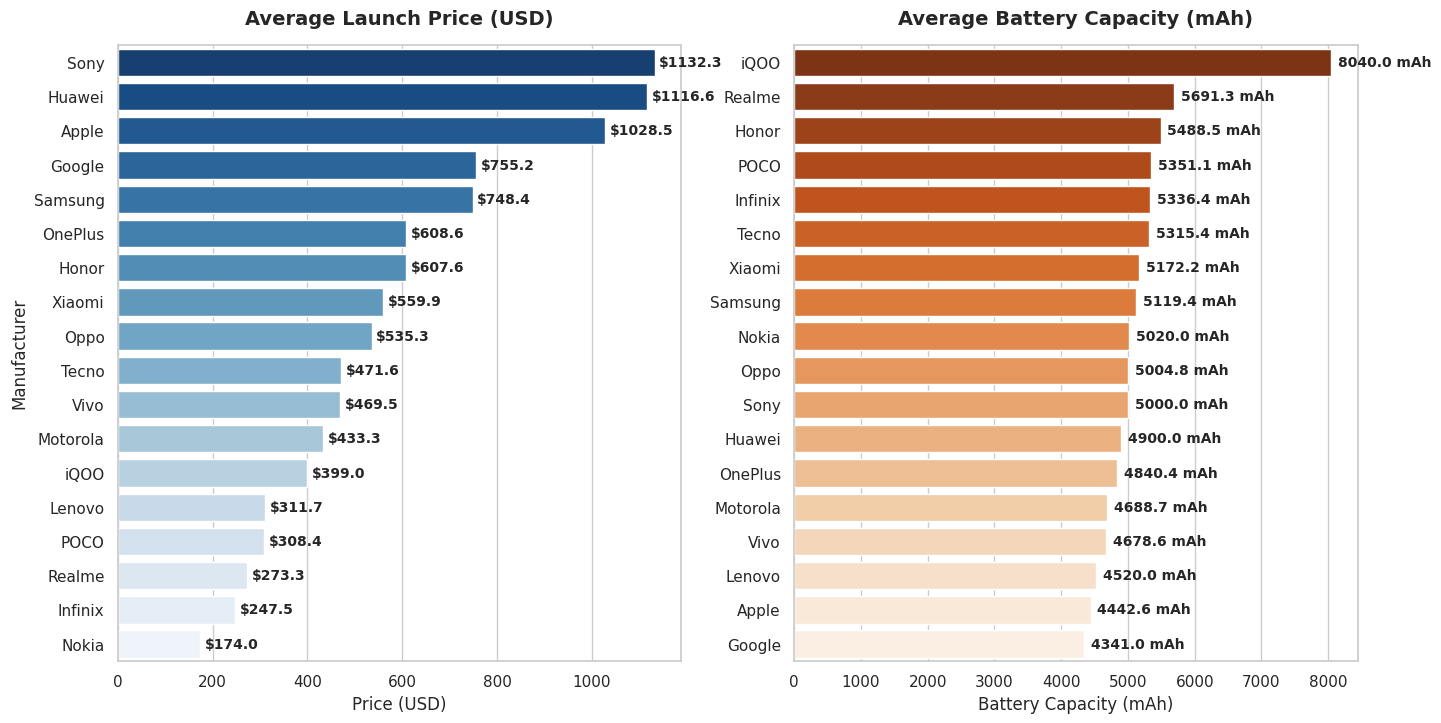

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Prepare data for plot 1
price_grp = df_unique.groupby('Company Name')['Launched Price (USA)'].mean().reset_index().sort_values(by='Launched Price (USA)', ascending=False)
battery_grp = df_unique.groupby('Company Name')['Battery Capacity'].mean().reset_index().sort_values(by='Battery Capacity', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Price
sns.barplot(x='Launched Price (USA)', y='Company Name', data=price_grp, ax=axes[0], palette='Blues_r')
axes[0].set_title('Average Launch Price (USD)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Price (USD)', fontsize=12)
axes[0].set_ylabel('Manufacturer', fontsize=12)

# Annotate left plot
for i, row in enumerate(price_grp.itertuples()):
    axes[0].text(row._2 + 10, i, f"${row._2:.1f}", va='center', fontsize=10, fontweight='semibold')

# Right plot: Battery
sns.barplot(x='Battery Capacity', y='Company Name', data=battery_grp, ax=axes[1], palette='Oranges_r')
axes[1].set_title('Average Battery Capacity (mAh)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Battery Capacity (mAh)', fontsize=12)
axes[1].set_ylabel('', fontsize=12)

# Annotate right plot
for i, row in enumerate(battery_grp.itertuples()):
    axes[1].text(row._2 + 100, i, f"{row._2:.1f} mAh", va='center', fontsize=10, fontweight='semibold')

plt.show()
plt.close()

# 상위 5대 제조사의 기기 무게 대 출시 가격 산점도 및 선형 회귀 분석 선

<Figure size 1000x600 with 0 Axes>

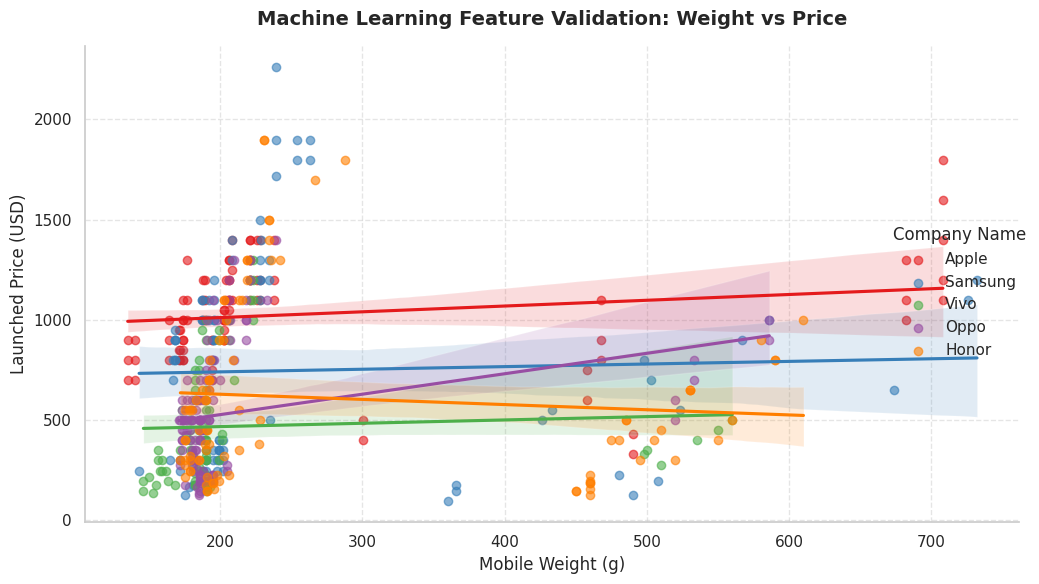

In [11]:
top_5_mfrs = df_unique['Company Name'].value_counts().head(5).index.tolist()
df_top5 = df_unique[df_unique['Company Name'].isin(top_5_mfrs)]

plt.figure(figsize=(10, 6))
sns.lmplot(x='Mobile Weight', y='Launched Price (USA)', hue='Company Name', data=df_top5,
           palette='Set1', height=6, aspect=1.5, scatter_kws={'alpha':0.6})

plt.title('Machine Learning Feature Validation: Weight vs Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mobile Weight (g)', fontsize=12)
plt.ylabel('Launched Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('weight_vs_price_regression.png', dpi=300)
plt.show()
plt.close()

# 가성비 분석 그래프

/tmp/ipykernel_4358/767443652.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




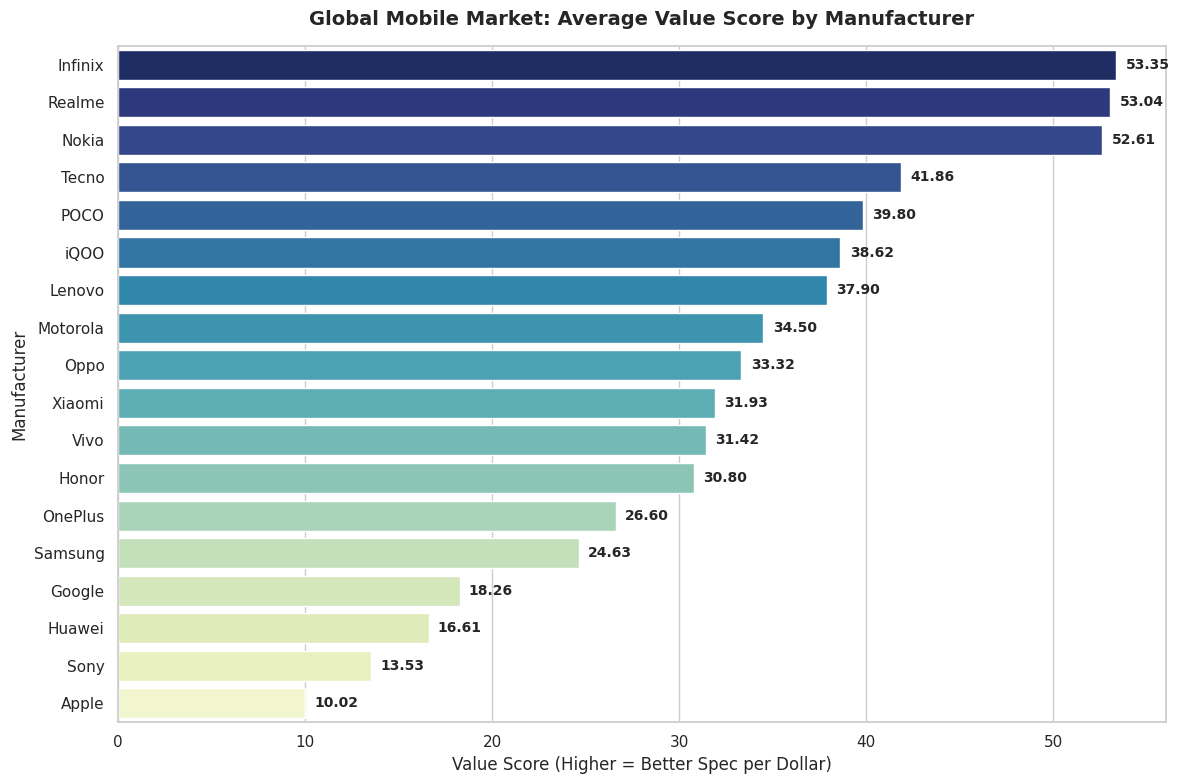

In [26]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "cleaned_mobiles_2025.csv"
with open(file_path, 'r', encoding='utf-8') as f:
    clean_lines = [line for line in f.readlines() if not (line.startswith('<<<<<<<') or line.startswith('=======') or line.startswith('>>>>>>>'))]

df = pd.read_csv(io.StringIO("".join(clean_lines)))
df.columns = df.columns.str.replace('\ufeff', '').str.strip()
df = df[df['Company Name'].str.contains('Company Name|HEAD|====|>>>>') == False]
df['Company Name'] = df['Company Name'].str.strip().replace({'Poco': 'POCO'})
df = df.drop_duplicates(subset=['Company Name', 'Model Name', 'Launched Price (USA)', 'Battery Capacity'])

# 2. 수치형 변환 및 가성비 변수(Value_Score) 생성
for col in ['Launched Price (USA)', 'RAM', 'Battery Capacity']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
df['Value_Score'] = ((df['RAM'] * 1000) + df['Battery Capacity']) / (df['Launched Price (USA)'] + 1)
df = df.dropna(subset=['Value_Score'])

# 3. 제조사별 평균 가성비 계산 및 정렬
value_grp = df.groupby('Company Name')['Value_Score'].mean().reset_index().sort_values(by='Value_Score', ascending=False)

# 4. 코랩 화면에 즉시 시각화 (보여주신 스타일 적용)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

# 가성비 수평 바 차트 그리기
sns.barplot(x='Value_Score', y='Company Name', data=value_grp, ax=ax, palette='YlGnBu_r')

# 차트 제목 및 라벨 설정
ax.set_title('Global Mobile Market: Average Value Score by Manufacturer', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Value Score (Higher = Better Spec per Dollar)', fontsize=12)
ax.set_ylabel('Manufacturer', fontsize=12)

# 막대 우측 끝에 소수점 둘째 자리까지 숫자 표시 (애노테이션)
for i, row in enumerate(value_grp.itertuples()):
    ax.text(row.Value_Score + 0.5, i, f"{row.Value_Score:.2f}", va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4358/3697485837.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




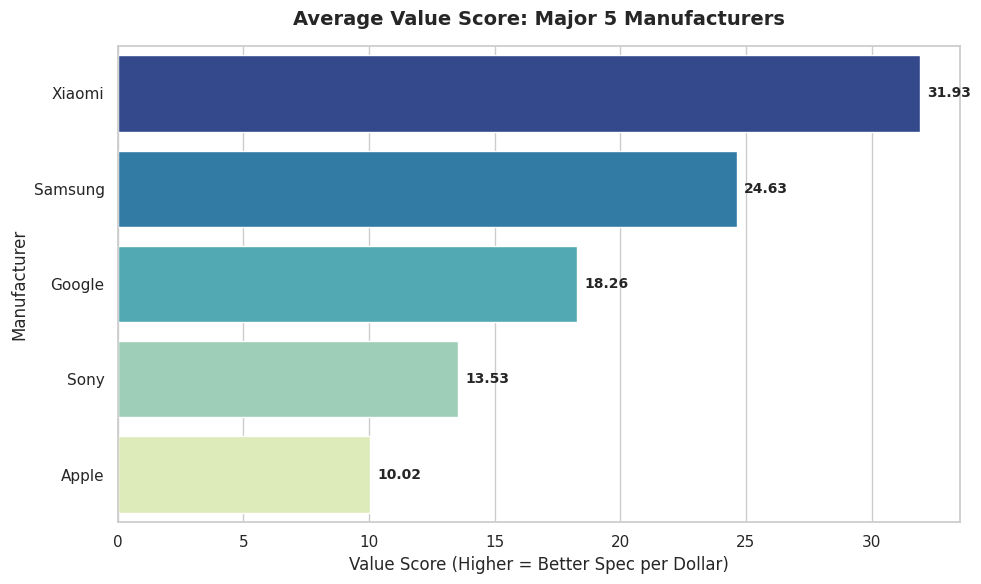

In [27]:
import io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 읽기 및 Git 찌꺼기 청소
file_path = "cleaned_mobiles_2025.csv"
with open(file_path, 'r', encoding='utf-8') as f:
    clean_lines = [line for line in f.readlines() if not (line.startswith('<<<<<<<') or line.startswith('=======') or line.startswith('>>>>>>>'))]

df = pd.read_csv(io.StringIO("".join(clean_lines)))
df.columns = df.columns.str.replace('\ufeff', '').str.strip()
df = df[df['Company Name'].str.contains('Company Name|HEAD|====|>>>>') == False]
df['Company Name'] = df['Company Name'].str.strip().replace({'Poco': 'POCO'})
df = df.drop_duplicates(subset=['Company Name', 'Model Name', 'Launched Price (USA)', 'Battery Capacity'])

# 2. 수치형 변환 및 가성비 변수(Value_Score) 생성
for col in ['Launched Price (USA)', 'RAM', 'Battery Capacity']:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
df['Value_Score'] = ((df['RAM'] * 1000) + df['Battery Capacity']) / (df['Launched Price (USA)'] + 1)
df = df.dropna(subset=['Value_Score'])

# 3. 제조사별 평균 가성비 계산 및 특정 5대 브랜드 필터링 🌟
value_grp = df.groupby('Company Name')['Value_Score'].mean().reset_index()

# 💡 샤오미, 애플, 삼성, 구글, 소니만 필터링 문법 추가
target_brands = ['Xiaomi', 'Apple', 'Samsung', 'Google', 'Sony']
value_grp = value_grp[value_grp['Company Name'].isin(target_brands)]

# 가성비 점수 기준 내림차순 정렬
value_grp = value_grp.sort_values(by='Value_Score', ascending=False)

# 4. 화면에 즉시 시각화 (5개 브랜드 맞춤 레이아웃 수 정)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# 가성비 수평 바 차트 그리기
sns.barplot(x='Value_Score', y='Company Name', data=value_grp, ax=ax, palette='YlGnBu_r')

# 차트 제목 및 라벨 설정
ax.set_title('Average Value Score: Major 5 Manufacturers', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Value Score (Higher = Better Spec per Dollar)', fontsize=12)
ax.set_ylabel('Manufacturer', fontsize=12)

# 막대 우측 끝에 소수점 둘째 자리까지 숫자 표시 (애노테이션)
for i, row in enumerate(value_grp.itertuples()):
    ax.text(row.Value_Score + 0.3, i, f"{row.Value_Score:.2f}", va='center', fontsize=10, fontweight='semibold')

plt.tight_layout()
plt.show()

# 하드웨어 스펙 및 가성비 지표(Value_Score)와 가격 간의 상관계수 히트맵

/tmp/ipykernel_4358/4258926529.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['Value_Score'] = ((df_unique['RAM'] * 1000) + df_unique['Battery Capacity']) / (df_unique['Launched Price (USA)'] + 1)


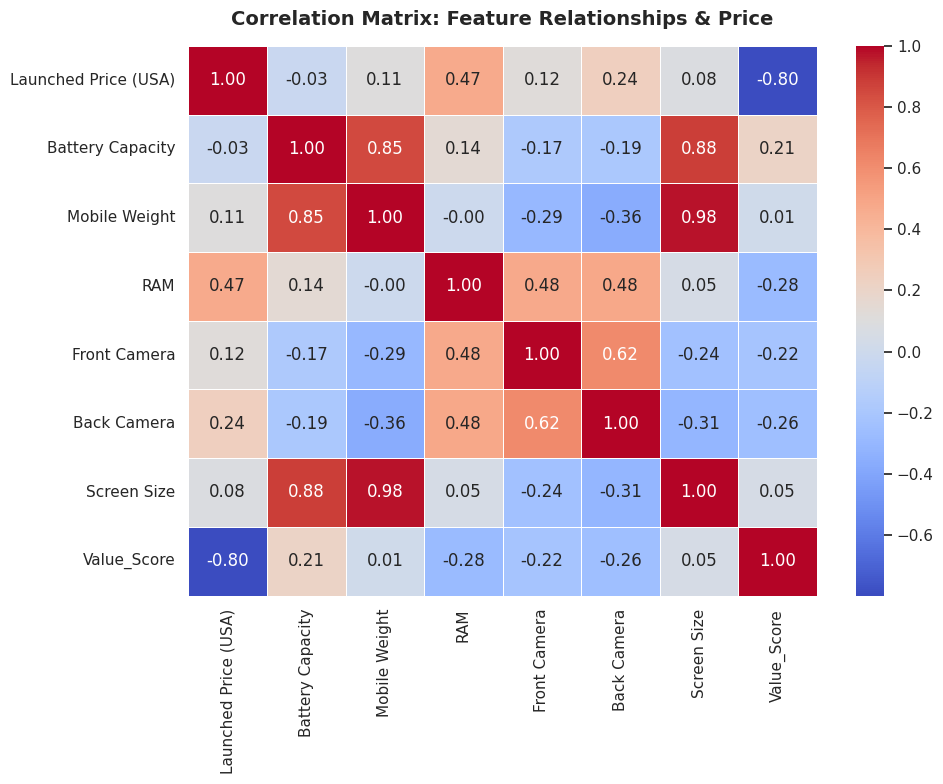

In [14]:
# Recalculate Value_Score to avoid any NaN values from the dual copy
df_unique['Value_Score'] = ((df_unique['RAM'] * 1000) + df_unique['Battery Capacity']) / (df_unique['Launched Price (USA)'] + 1)

# Select relevant features for the correlation matrix
corr_cols = ['Launched Price (USA)', 'Battery Capacity', 'Mobile Weight', 'RAM', 'Front Camera', 'Back Camera', 'Screen Size', 'Value_Score']
corr_matrix = df_unique[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Feature Relationships & Price', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()